In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/user1/WhatDoLLMsWant


# Persona vs explicit contract — "I am a poor student" vs "I prefer 4GB / 8GB"

Two ways to steer the model toward a cheaper laptop, with no contract in either:

| run | prompt prefix | folder |
|---|---|---|
| `none` | I am looking to buy a laptop. | laptops_robustness |
| **`student`** | **I am a student and I do not have much money.** I am looking to buy a laptop. | laptops_persona |
| `ram=4GB` | I am looking to buy a laptop. **I prefer 4 GB ram.** | laptops_robustness |
| `ram=8GB` | I am looking to buy a laptop. **I prefer 8 GB ram.** | laptops_robustness |
| **`editor`** | **I am a professional video editor.** I am looking to buy a laptop. | laptops_persona |
| `ram=16GB` | I am looking to buy a laptop. **I prefer 16 GB ram.** | laptops_robustness |

The persona names **no spec**: whatever moves, the model inferred. qwen-32B and qwen-72B
(qwen-72B `editor` has not landed).

**PMI.** The persona runs were collected with PMI off, the others with PMI on. Everything here is
a feature weight, a utility rank or the position-corrected D, all immune to that constant; γ is
not used.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from src.bt import FeatureBT

FIGDIR = "figs/persona"
os.makedirs(FIGDIR, exist_ok=True)
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#d6d5d1",
    "axes.labelcolor": INK, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "axes.grid": True,
    "grid.color": "#e8e7e3", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "figure.dpi": 110, "font.size": 10,
    "savefig.bbox": "tight", "savefig.dpi": 200,
})
BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
SCREEN, RAM = ["13-inch", "14-inch", "16-inch"], ["4GB", "8GB", "16GB"]
LEVELS = {"brand": BRANDS, "screen": SCREEN, "ram": RAM}
LAPTOPS = [(b, s, r) for b in BRANDS for s in SCREEN for r in RAM]
MODELS = [("qwen", "32"), ("qwen", "72")]
ORDER = ["none", "student", "ram=4GB", "ram=8GB", "editor", "ram=16GB"]
# one colour per run (validated categorical slots); the persona runs are the warm ones
RUN_COLOR = {"none": "#8d8b85", "student": "#eb6834", "ram=4GB": "#2a78d6", "ram=8GB": "#1baf7a",
             "editor": "#e87ba4", "ram=16GB": "#4a3aa7"}


def load():
    """Complete runs only, one per (model, run) - asserted."""
    R = {}
    for base in ["data/laptops_robustness", "data/laptops_persona"]:
        for r in sorted(os.listdir(base)):
            cf, sc = f"{base}/{r}/config.json", f"{base}/{r}/scores.csv"
            if not (os.path.isfile(cf) and os.path.isfile(sc)):
                continue
            c = json.load(open(cf))
            m = (c["model_family"], str(c["model_size"]))
            fr, cid = c["frame"]["name"], c["constraints_id"]
            run = cid if fr == "shopping" else fr if cid == "none" else None
            if m not in MODELS or run not in ORDER or (fr != "shopping" and fr not in ("student", "editor")):
                continue
            d = pd.read_csv(sc)
            if len(d) != 9900:
                continue
            assert (m, run) not in R, f"two complete runs for {m} {run}"
            R[(m, run)] = d
    return R


def D(d, f, u, v):
    """Position-corrected margin of level u over v on feature f, other features tied: one value
    per (pair, template)."""
    o = [x for x in ("brand", "screen", "ram") if x != f]
    t = d[(d[f"a_{o[0]}"] == d[f"b_{o[0]}"]) & (d[f"a_{o[1]}"] == d[f"b_{o[1]}"]) & d[f"a_{f}"].isin([u, v])
          & d[f"b_{f}"].isin([u, v]) & (d[f"a_{f}"] != d[f"b_{f}"])]
    val = np.where(t[f"a_{f}"] == u, t.score_a - t.score_b, t.score_b - t.score_a)
    return pd.Series(val).groupby((t[f"a_{o[0]}"] + t[f"a_{o[1]}"] + t.template_idx.astype(str)).values).mean()


RUNS = load()
FITS = {k: FeatureBT(r2_warn=None).fit(d) for k, d in RUNS.items()}
for m in MODELS:
    print(f"{m[0]}-{m[1]}B:", [r for r in ORDER if (m, r) in RUNS])

qwen-32B: ['none', 'student', 'ram=4GB', 'ram=8GB', 'editor', 'ram=16GB']
qwen-72B: ['none', 'student', 'ram=4GB', 'ram=8GB', 'ram=16GB']


## P1 — every feature weight: the persona vs the explicit contracts

One panel per model. x = each level of each feature, y = its weight (centred within the feature,
so 0 = the average level). One line per run. The question: does `student` look like `ram=4GB`,
like `ram=8GB`, or like something else?

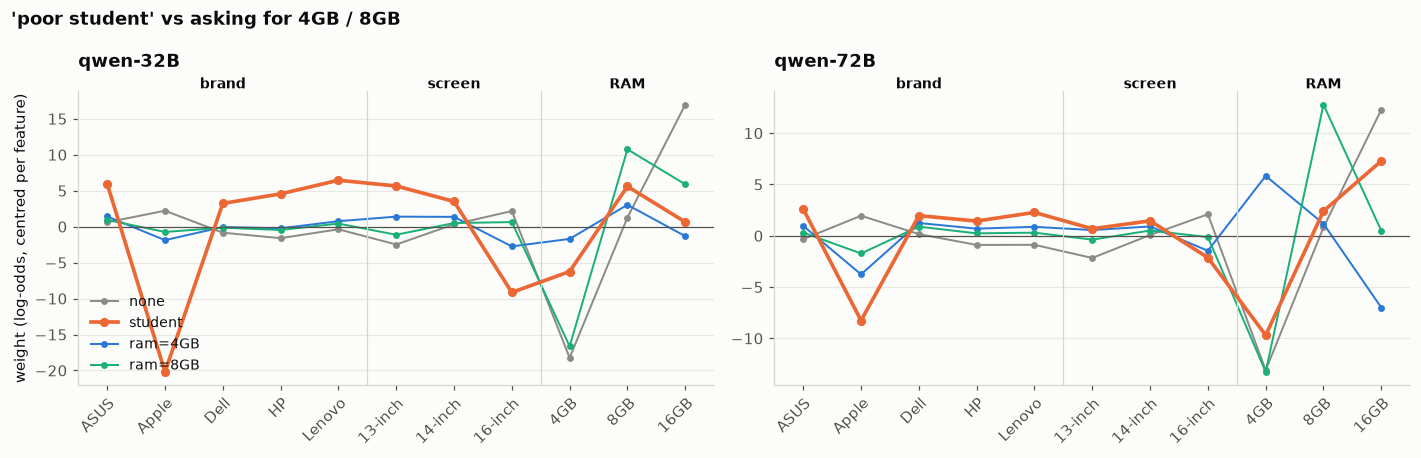

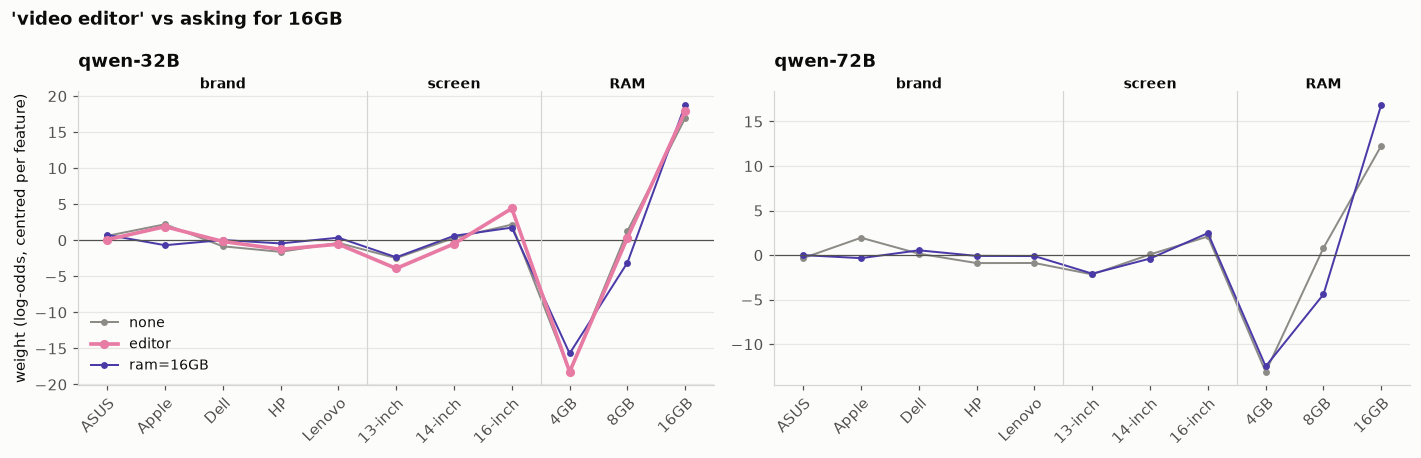

In [3]:
def weights_panel(ax, m, runs):
    lv = [(f, l) for f in ("brand", "screen", "ram") for l in LEVELS[f]]
    x = np.arange(len(lv))
    for run in runs:
        if (m, run) not in FITS:
            continue
        y = [FITS[(m, run)].weights_[f][l] for f, l in lv]
        persona = run in ("student", "editor")
        ax.plot(x, y, "-o", color=RUN_COLOR[run], lw=2.4 if persona else 1.3, ms=5 if persona else 3.5,
                label=run, zorder=3 if persona else 2)
    ax.axhline(0, color=INK_MUTED, lw=0.8)
    for k in (5, 8):
        ax.axvline(k - 0.5, color="#d6d5d1", lw=0.8)
    ax.set_xticks(x, [l for _, l in lv], rotation=45, ha="right", rotation_mode="anchor")
    for xc, t in [(2, "brand"), (6, "screen"), (9, "RAM")]:
        ax.text(xc, 1.01, t, transform=ax.get_xaxis_transform(), ha="center", fontweight="bold", fontsize=9)
    ax.set_title(f"{m[0]}-{m[1]}B", loc="left", fontweight="bold", pad=16)
    ax.grid(axis="x", visible=False)


for runs, tag, title in [(["none", "student", "ram=4GB", "ram=8GB"], "P1_student", "'poor student' vs asking for 4GB / 8GB"),
                         (["none", "editor", "ram=16GB"], "P1b_editor", "'video editor' vs asking for 16GB")]:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=False)
    for ax, m in zip(axes, MODELS):
        weights_panel(ax, m, runs)
    axes[0].set_ylabel("weight (log-odds, centred per feature)")
    axes[0].legend(frameon=False, fontsize=9, loc="lower left")
    fig.suptitle(title, x=0.01, ha="left", fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(FIGDIR, tag + ".png"), facecolor=SURFACE)
    plt.show()

## P2 — the RAM comparisons, head to head

*Ceteris paribus* pairs (brand and screen tied), 75 per bar: the % where the **lower** RAM level
wins, by the position-corrected D. Three comparisons, one panel each.

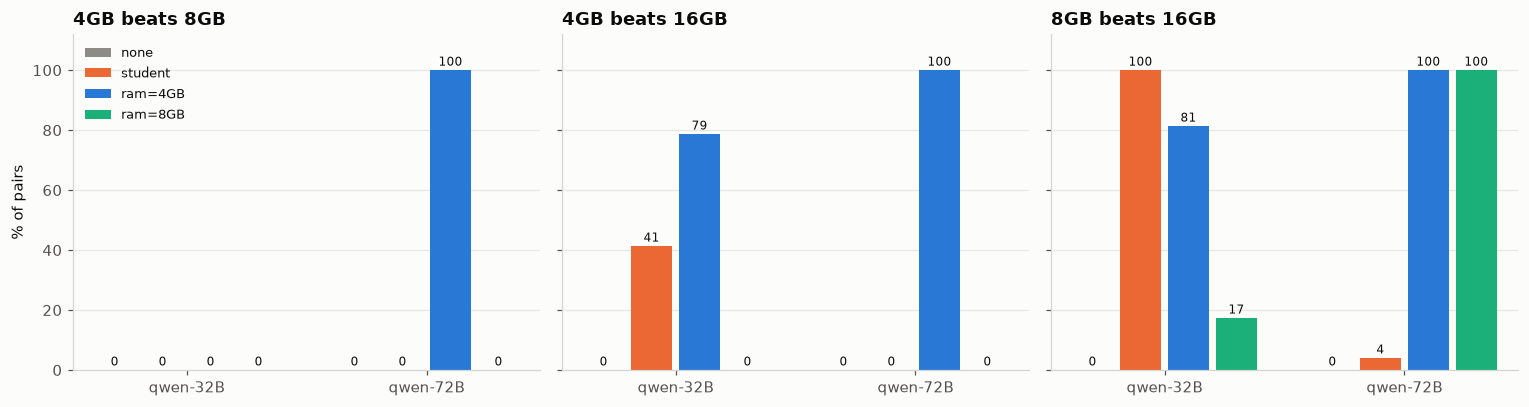

   model      run  4GB beats 8GB %  D 4GB-8GB  4GB beats 16GB %  D 4GB-16GB  8GB beats 16GB %  D 8GB-16GB
qwen-32B     none              0.0     -29.21              0.00      -29.15              0.00      -27.35
qwen-32B  student              0.0     -18.54             41.33       -0.26            100.00       12.60
qwen-32B  ram=4GB              0.0     -13.98             78.67        1.80             81.33        2.99
qwen-32B  ram=8GB              0.0     -31.54              0.00      -22.03             17.33       -2.56
qwen-32B   editor              0.0     -28.71              0.00      -28.88              0.00      -28.29
qwen-32B ram=16GB              0.0     -22.93              0.00      -30.74              0.00      -30.49
qwen-72B     none              0.0     -22.60              0.00      -22.58              0.00      -20.35
qwen-72B  student              0.0     -18.26              0.00      -14.52              4.00       -6.68
qwen-72B  ram=4GB            100.0       7.99 

In [4]:
rows = []
for m in MODELS:
    for run in ORDER:
        if (m, run) not in RUNS:
            continue
        d = RUNS[(m, run)]
        r = {"model": f"{m[0]}-{m[1]}B", "run": run}
        for u, v in [("4GB", "8GB"), ("4GB", "16GB"), ("8GB", "16GB")]:
            x = D(d, "ram", u, v)
            r[f"{u} beats {v} %"] = 100 * (x > 0).mean()
            r[f"D {u}-{v}"] = x.mean()
        rows.append(r)
HH = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
runs = ["none", "student", "ram=4GB", "ram=8GB"]
for ax, (u, v) in zip(axes, [("4GB", "8GB"), ("4GB", "16GB"), ("8GB", "16GB")]):
    for i, m in enumerate(MODELS):
        for j, run in enumerate(runs):
            row = HH[(HH.model == f"{m[0]}-{m[1]}B") & (HH.run == run)]
            if row.empty:
                continue
            val = row[f"{u} beats {v} %"].iloc[0]
            xpos = i * (len(runs) + 1) + j
            ax.bar(xpos, val, 0.85, color=RUN_COLOR[run], label=run if i == 0 else None, zorder=2)
            ax.text(xpos, val + 1.5, f"{val:.0f}", ha="center", fontsize=8)
    ax.set_xticks([1.5, 1.5 + len(runs) + 1], [f"{m[0]}-{m[1]}B" for m in MODELS])
    ax.set_ylim(0, 112)
    ax.set_title(f"{u} beats {v}", loc="left", fontweight="bold")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("% of pairs")
axes[0].legend(frameon=False, fontsize=8.5, loc="upper left")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "P2_ram_head_to_head.png"), facecolor=SURFACE)
plt.show()
pd.set_option("display.width", 220)
print(HH.round(2).to_string(index=False))

## P3 — what else the persona moved, and which contract it resembles

Left: the weights that change most between `none` and the persona, side by side with what the
explicit contract changed. Right (printed): Spearman between the persona's 45 laptop utilities
and each other run's — which run ranks the laptops most like the persona does.

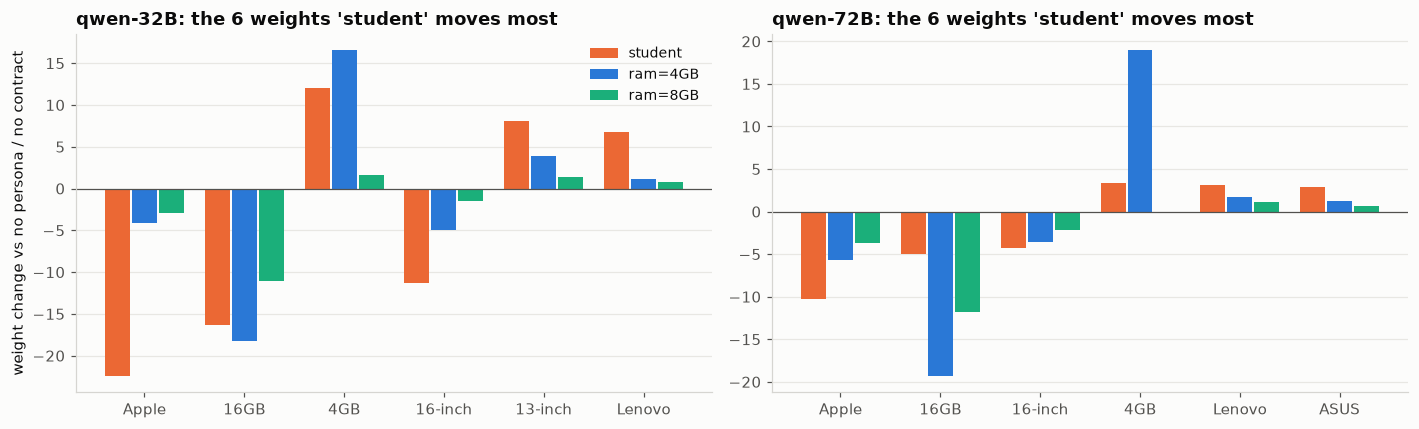

Spearman of the persona's 45 laptop utilities with each run
   model persona   none  ram=4GB  ram=8GB  ram=16GB
qwen-32B student -0.042    0.791    0.367     0.103
qwen-32B  editor  0.994   -0.102    0.519     0.984
qwen-72B student  0.700   -0.587    0.606     0.789


In [5]:
rows = []
for m in MODELS:
    base = FITS[(m, "none")].weights_
    for run in ("student", "ram=4GB", "ram=8GB", "editor", "ram=16GB"):
        if (m, run) not in FITS:
            continue
        w = FITS[(m, run)].weights_
        for f in LEVELS:
            for l in LEVELS[f]:
                rows.append({"model": f"{m[0]}-{m[1]}B", "run": run, "level": l, "change": w[f][l] - base[f][l]})
CH = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, m in zip(axes, MODELS):
    mm = f"{m[0]}-{m[1]}B"
    t = CH[(CH.model == mm)].pivot(index="level", columns="run", values="change")
    top = t["student"].abs().sort_values(ascending=False).index[:6]
    cols = [r for r in ("student", "ram=4GB", "ram=8GB") if r in t]
    x = np.arange(len(top))
    for j, run in enumerate(cols):
        ax.bar(x + (j - 1) * 0.27, t.loc[top, run], 0.25, color=RUN_COLOR[run], label=run, zorder=2)
    ax.axhline(0, color=INK_MUTED, lw=0.8)
    ax.set_xticks(x, top)
    ax.set_title(f"{mm}: the 6 weights 'student' moves most", loc="left", fontweight="bold")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("weight change vs no persona / no contract")
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "P3_what_moved.png"), facecolor=SURFACE)
plt.show()

U = {k: np.array([f.utility(dict(brand=b, screen=s, ram=r)) for b, s, r in LAPTOPS]) for k, f in FITS.items()}
rows = []
for m in MODELS:
    for persona in ("student", "editor"):
        if (m, persona) not in U:
            continue
        rows.append({"model": f"{m[0]}-{m[1]}B", "persona": persona,
                     **{run: spearmanr(U[(m, persona)], U[(m, run)])[0] for run in ORDER
                        if run not in ("student", "editor") and (m, run) in U}})
print("Spearman of the persona's 45 laptop utilities with each run")
print(pd.DataFrame(rows).round(3).to_string(index=False))

## P4 — rank flow: default → persona, per model

Every laptop's rank (1 = most preferred, from the additive BT utility) with no persona and with
each persona. **Colour = RAM** (the persona names no spec, so there is no "meets the contract"
colouring here); **Apple is dashed**. Labels on both sides; bold = the laptop's rank changed by
10 or more places.

/tmp/ipykernel_338417/989200380.py:25: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([0, 1], [r0[l], r1[l]], "-o", color=RAM_COLOR[l[2]], lw=1.8 if big else 1.0, ms=3,
/tmp/ipykernel_338417/989200380.py:25: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([0, 1], [r0[l], r1[l]], "-o", color=RAM_COLOR[l[2]], lw=1.8 if big else 1.0, ms=3,
/tmp/ipykernel_338417/989200380.py:25: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([0, 1], [r0[l], r1[l]], "-o", color=RAM_COLOR[l[2]], lw=1.8 if big else 1.0, ms=3,


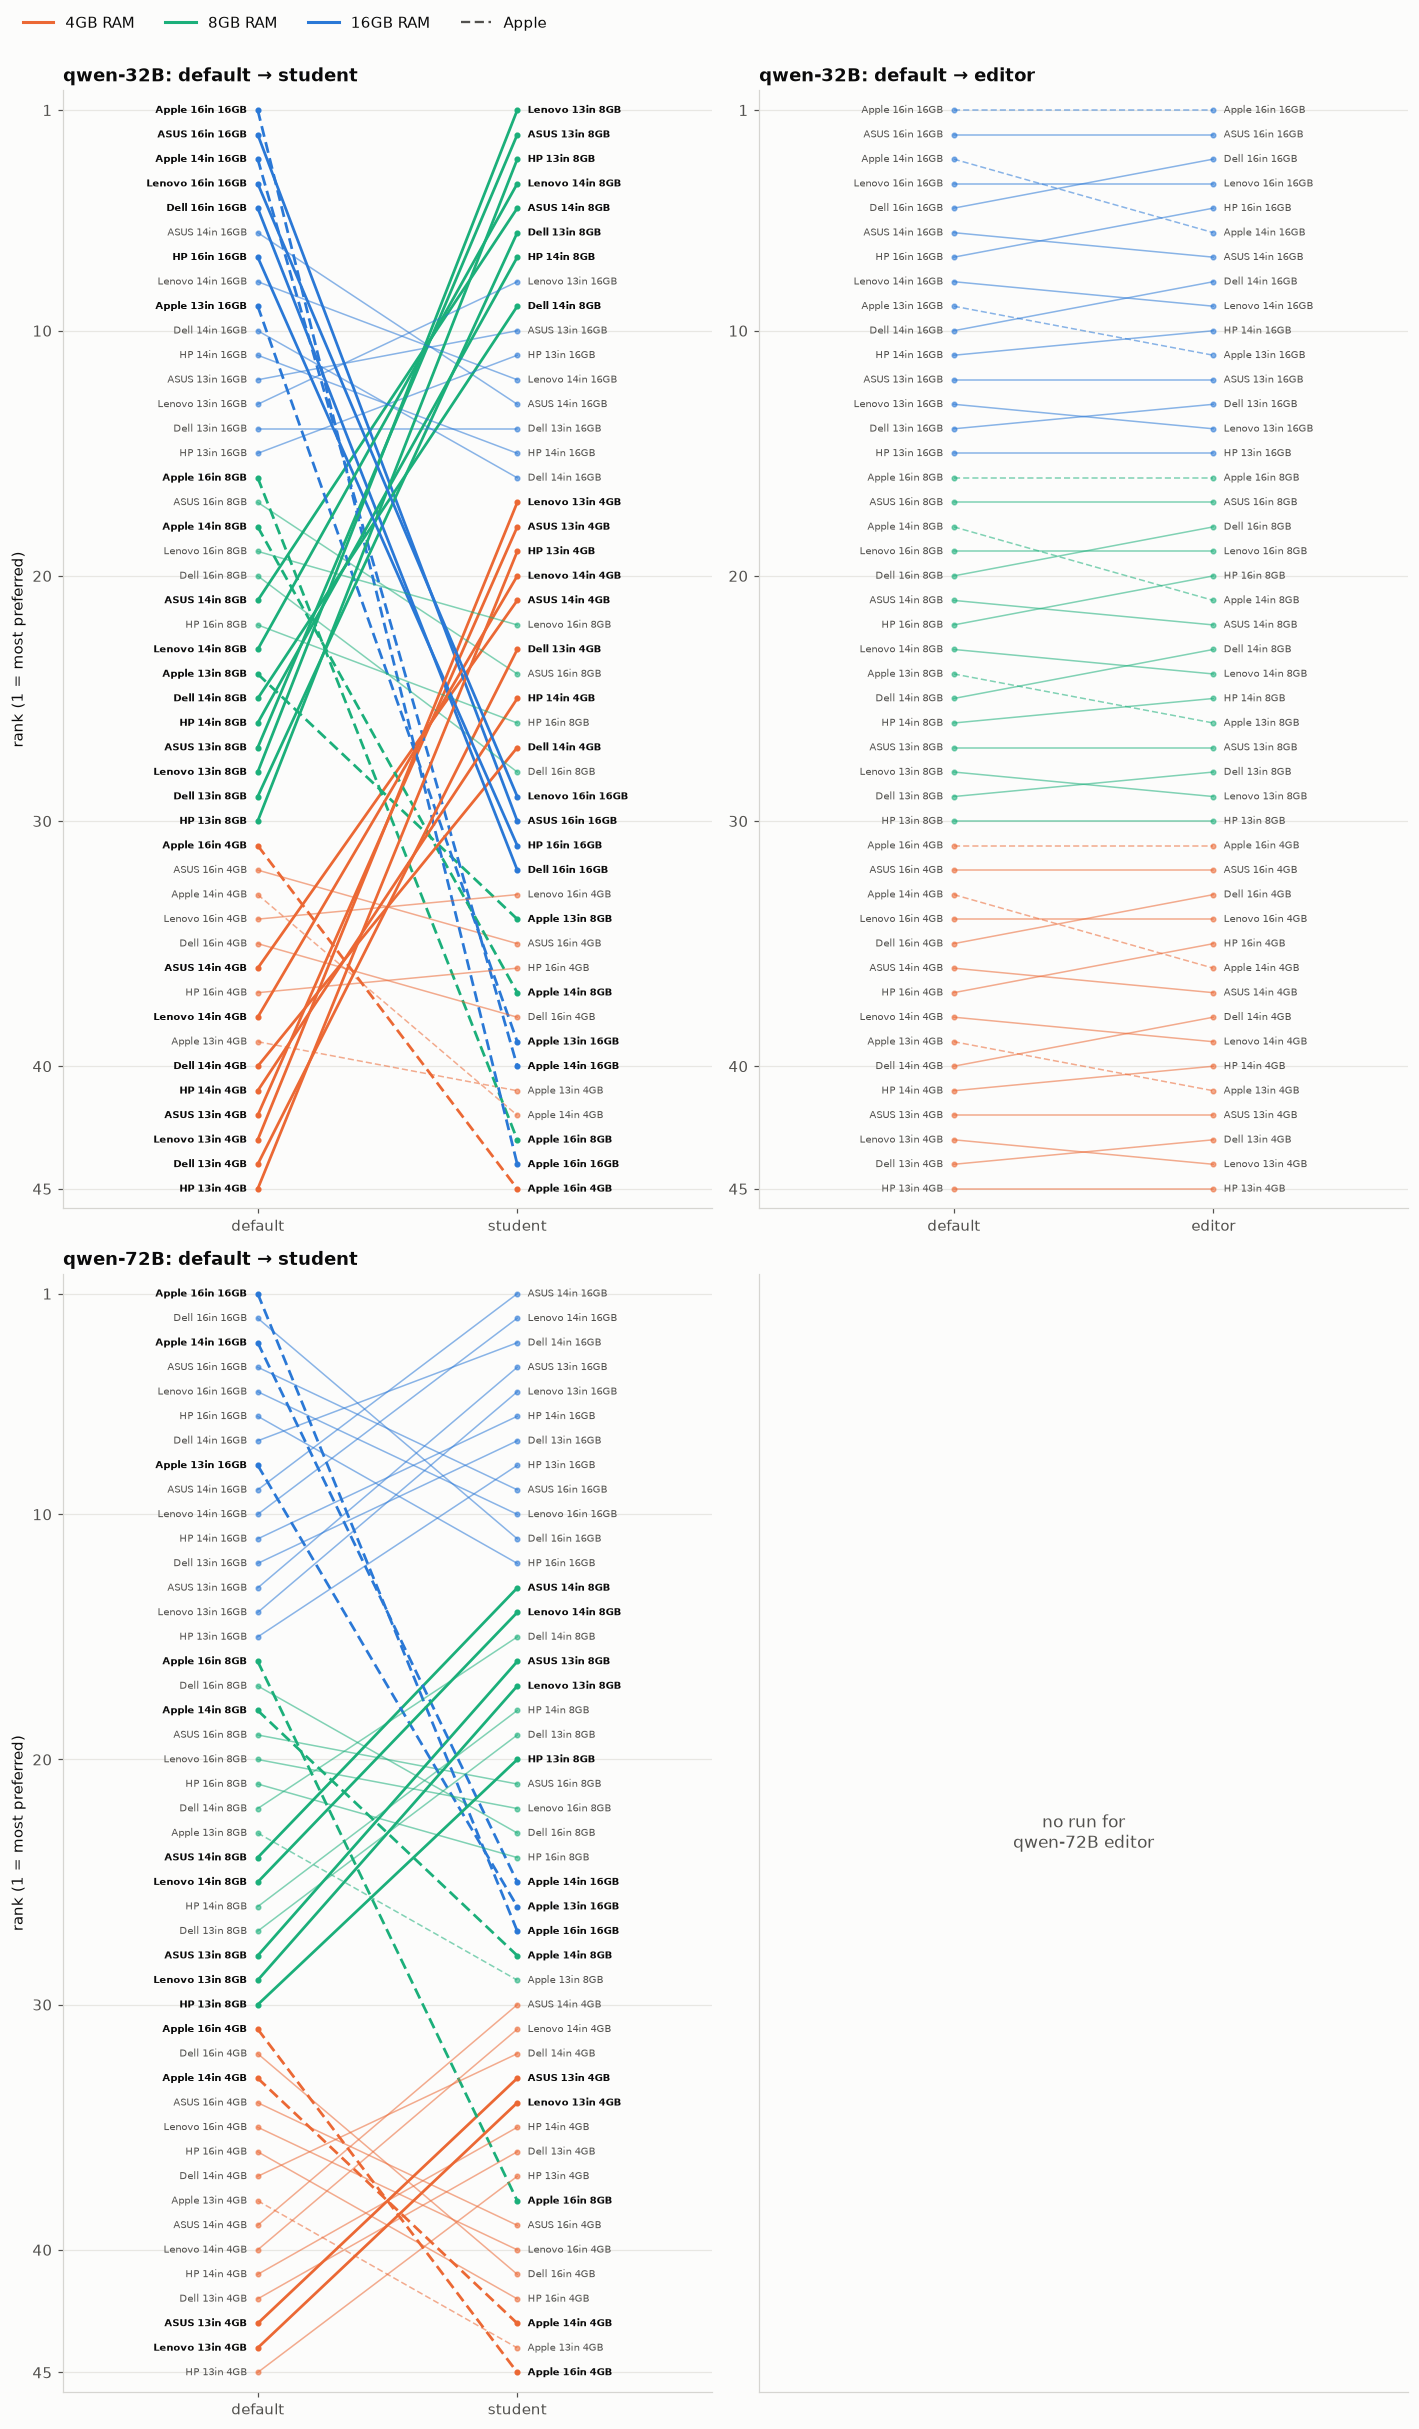

   model persona                                               biggest rises                                                 biggest falls      #1 default      #1 persona
qwen-32B student   Lenovo 13in 8GB +27, HP 13in 8GB +27, Lenovo 13in 4GB +26 Apple 16in 16GB -43, Apple 14in 16GB -37, Apple 13in 16GB -30 Apple 16in 16GB Lenovo 13in 8GB
qwen-32B  editor             HP 16in 8GB +2, HP 16in 4GB +2, HP 16in 16GB +2      Apple 14in 16GB -3, Apple 14in 4GB -3, Apple 14in 8GB -3 Apple 16in 16GB Apple 16in 16GB
qwen-72B student Lenovo 13in 8GB +12, ASUS 13in 8GB +12, Lenovo 14in 8GB +11  Apple 16in 16GB -26, Apple 14in 16GB -22, Apple 16in 8GB -22 Apple 16in 16GB  ASUS 14in 16GB


In [6]:
RAM_COLOR = {"4GB": "#eb6834", "8GB": "#1baf7a", "16GB": "#2a78d6"}   # validated categorical slots
PERSONAS = ["student", "editor"]


def rank_of(m, run):
    f = FITS[(m, run)]
    u = pd.Series({l: f.utility(dict(brand=l[0], screen=l[1], ram=l[2])) for l in LAPTOPS})
    return u.rank(ascending=False, method="first")


def short(l):
    return f"{l[0]} {l[1].replace('-inch', 'in')} {l[2]}"


def flow(ax, m, persona, fs=6.5):
    if (m, persona) not in RUNS:
        ax.text(0.5, 0.5, f"no run for\n{m[0]}-{m[1]}B {persona}", transform=ax.transAxes,
                ha="center", va="center", color=INK_MUTED, fontsize=11)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        return
    r0, r1 = rank_of(m, "none"), rank_of(m, persona)
    for l in LAPTOPS:
        apple = l[0] == "Apple"
        big = abs(r1[l] - r0[l]) >= 10
        ax.plot([0, 1], [r0[l], r1[l]], "-o", color=RAM_COLOR[l[2]], lw=1.8 if big else 1.0, ms=3,
                ls=(0, (4, 2)) if apple else "-", alpha=1 if big else 0.55)
        for x, r, ha, off in [(0, r0[l], "right", -0.04), (1, r1[l], "left", 0.04)]:
            ax.text(x + off, r, short(l), ha=ha, va="center", fontsize=fs,
                    color=INK if big else INK_MUTED, fontweight="bold" if big else "normal")
    ax.set_xticks([0, 1], ["default", persona])
    ax.set_xlim(-0.75, 1.75)
    ax.set_ylim(45.8, 0.2)
    ax.set_yticks([1, 10, 20, 30, 40, 45])
    ax.grid(axis="x", visible=False)
    ax.set_title(f"{m[0]}-{m[1]}B: default → {persona}", loc="left", fontweight="bold")


fig, axes = plt.subplots(len(MODELS), len(PERSONAS), figsize=(13, 11 * len(MODELS)), squeeze=False)
for i, m in enumerate(MODELS):
    for j, persona in enumerate(PERSONAS):
        flow(axes[i, j], m, persona)
    axes[i, 0].set_ylabel("rank (1 = most preferred)")
hs = [plt.Line2D([], [], color=c, lw=2, label=f"{r} RAM") for r, c in RAM_COLOR.items()]
hs.append(plt.Line2D([], [], color=INK_MUTED, lw=1.5, ls=(0, (4, 2)), label="Apple"))
fig.legend(handles=hs, loc="upper left", ncol=4, frameon=False, bbox_to_anchor=(0.01, 1.005), fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.985))
fig.savefig(os.path.join(FIGDIR, "P4_rank_flow.png"), facecolor=SURFACE)
plt.show()

# the biggest movers, per model and persona
rows = []
for m in MODELS:
    for persona in PERSONAS:
        if (m, persona) not in RUNS:
            continue
        mv = (rank_of(m, "none") - rank_of(m, persona)).sort_values()
        rows.append({"model": f"{m[0]}-{m[1]}B", "persona": persona,
                     "biggest rises": ", ".join(f"{short(l)} +{int(v)}" for l, v in mv[::-1][:3].items()),
                     "biggest falls": ", ".join(f"{short(l)} {int(v)}" for l, v in mv[:3].items()),
                     "#1 default": short(rank_of(m, "none").idxmin()), "#1 persona": short(rank_of(m, persona).idxmin())})
pd.set_option("display.max_colwidth", 80)
print(pd.DataFrame(rows).to_string(index=False))

## P5 — is the persona's effect linked to the model's own default preferences?

**Left:** one point per laptop. x = its default utility, y = how much the persona changed it.
A downward trend = the persona moves the laptops the model liked most down and the ones it liked
least up. Colour = RAM, ★ = Apple.

**Right:** one point per feature level. x = the level's default weight, y = its weight under the
persona. Reference lines: **y = x** (no change), **y = 0** (indifferent), **y = −x** (exact mirror).
A slope between 0 and −1 flattens the feature, below −1 reverses it beyond the default.

The `ram=4GB` contract is drawn faintly for comparison.

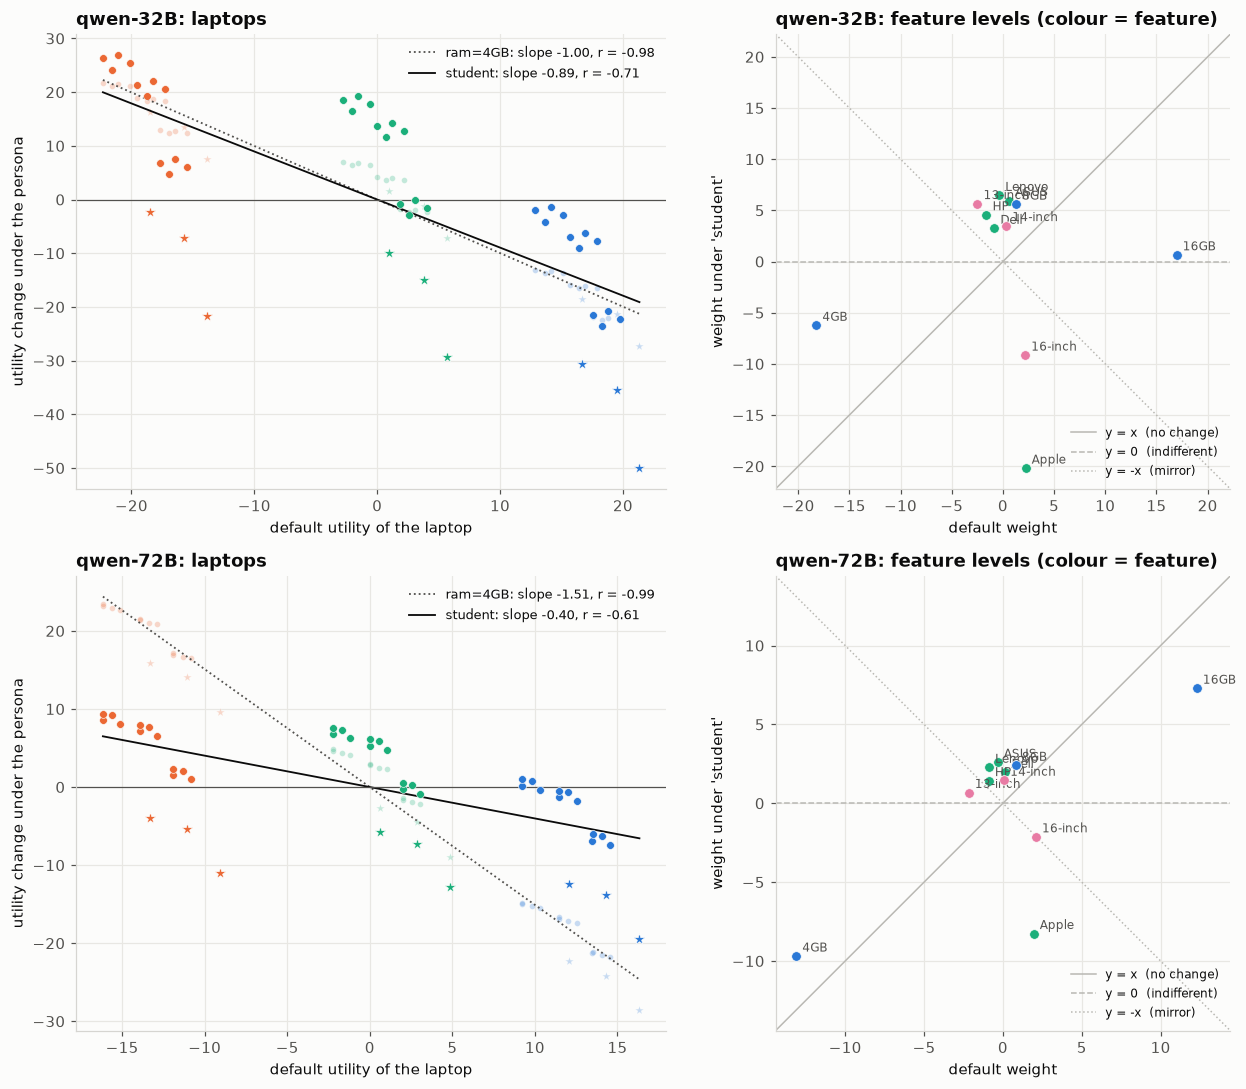

slope of the new weights on the default ones, per feature: 1 = unchanged, 0 = flattened, -1 = mirrored
   model     run feature  slope (new on default)  range default  range new
qwen-32B student   brand                   -6.16           3.82      26.64
qwen-32B student  screen                   -2.98           4.65      14.80
qwen-32B student     ram                    0.21          35.19      11.83
qwen-32B ram=4GB   brand                   -0.36           3.82       3.30
qwen-32B ram=4GB  screen                   -0.82           4.65       4.14
qwen-32B ram=4GB     ram                    0.02          35.19       4.74
qwen-32B  editor   brand                    0.76           3.82       3.14
qwen-32B  editor  screen                    1.74           4.65       8.33
qwen-32B  editor     ram                    1.02          35.19      36.15
qwen-72B student   brand                   -3.61           2.84      10.87
qwen-72B student  screen                   -0.64           4.26       3.

In [7]:
FEAT_COLOR = {"brand": "#1baf7a", "screen": "#e87ba4", "ram": "#2a78d6"}


def util(m, run):
    f = FITS[(m, run)]
    return pd.Series({l: f.utility(dict(brand=l[0], screen=l[1], ram=l[2])) for l in LAPTOPS})


fig, axes = plt.subplots(len(MODELS), 2, figsize=(12, 5 * len(MODELS)))
for i, m in enumerate(MODELS):
    u0 = util(m, "none")
    ax = axes[i, 0]
    for run, alpha, size in [("ram=4GB", 0.25, 14), ("student", 1.0, 26)]:
        du = util(m, run) - u0
        for l in LAPTOPS:
            ax.scatter(u0[l], du[l], s=size * (2.2 if l[0] == "Apple" else 1), marker="*" if l[0] == "Apple" else "o",
                       color=RAM_COLOR[l[2]], alpha=alpha, edgecolor=SURFACE, lw=0.4, zorder=3 if run == "student" else 2)
        b = np.polyfit(u0, du, 1)
        xx = np.array([u0.min(), u0.max()])
        ax.plot(xx, np.polyval(b, xx), color=INK if run == "student" else INK_MUTED, lw=1.2,
                ls="-" if run == "student" else ":", label=f"{run}: slope {b[0]:.2f}, r = {np.corrcoef(u0, du)[0, 1]:.2f}")
    ax.axhline(0, color=INK_MUTED, lw=0.8)
    ax.set_xlabel("default utility of the laptop")
    ax.set_ylabel("utility change under the persona")
    ax.set_title(f"{m[0]}-{m[1]}B: laptops", loc="left", fontweight="bold")
    ax.legend(frameon=False, fontsize=8.5, loc="upper right")

    ax = axes[i, 1]
    w0, w1 = FITS[(m, "none")].weights_, FITS[(m, "student")].weights_
    lim = 1.1 * max(abs(v) for f in LEVELS for l in LEVELS[f] for v in (w0[f][l], w1[f][l]))
    for slope, ls, lab in [(1, "-", "y = x  (no change)"), (0, "--", "y = 0  (indifferent)"), (-1, ":", "y = -x  (mirror)")]:
        ax.plot([-lim, lim], [-slope * lim, slope * lim], color="#b9b8b3", lw=1, ls=ls, label=lab, zorder=1)
    for f in LEVELS:
        for l in LEVELS[f]:
            ax.scatter(w0[f][l], w1[f][l], s=40, color=FEAT_COLOR[f], zorder=3, edgecolor=SURFACE, lw=0.5)
            ax.annotate(l, (w0[f][l], w1[f][l]), xytext=(4, 3), textcoords="offset points", fontsize=8, color=INK_MUTED)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    ax.set_xlabel("default weight"); ax.set_ylabel("weight under 'student'")
    ax.set_title(f"{m[0]}-{m[1]}B: feature levels (colour = feature)", loc="left", fontweight="bold")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "P5_link_to_default.png"), facecolor=SURFACE)
plt.show()

rows = []
for m in MODELS:
    w0 = FITS[(m, "none")].weights_
    for run in ("student", "ram=4GB", "editor"):
        if (m, run) not in FITS:
            continue
        w1 = FITS[(m, run)].weights_
        for f in LEVELS:
            a = np.array([w0[f][l] for l in LEVELS[f]]); b = np.array([w1[f][l] for l in LEVELS[f]])
            rows.append({"model": f"{m[0]}-{m[1]}B", "run": run, "feature": f,
                         "slope (new on default)": np.polyfit(a, b, 1)[0],
                         "range default": a.max() - a.min(), "range new": b.max() - b.min()})
print("slope of the new weights on the default ones, per feature: 1 = unchanged, 0 = flattened, -1 = mirrored")
print(pd.DataFrame(rows).round(2).to_string(index=False))